# Week 9 - Decision Trees
### CSE 432 / 532 - Machine Learning

**Contents:**

- [Part 1 -- What is a Decision Tree? (Sec. 9.1)](#Part-1----What-is-a-Decision-Tree?-(Sec.-9.1))
- [Part 2 -- How Trees Are Trained: Impurity and Splitting (Sec. 9.1)](#Part-2----How-Trees-Are-Trained:-Impurity-and-Splitting-(Sec.-9.1))
- [Part 3 -- Decision Tree Algorithms: ID3, C5.0, CART (Sec. 9.2)](#Part-3----Decision-Tree-Algorithms:-ID3,-C5.0,-CART-(Sec.-9.2))
- [Part 4 -- Classification Trees in scikit-learn](#Part-4----Classification-Trees-in-scikit-learn)
- [Part 5 -- Controlling Tree Growth: Early Stopping and Pruning](#Part-5----Controlling-Tree-Growth:-Early-Stopping-and-Pruning)
- [Part 6 -- Decision Trees for Regression (Sec. 9.3)](#Part-6----Decision-Trees-for-Regression-(Sec.-9.3))
- [Wrap-Up: Advantages, Disadvantages, and What is Next](#Wrap-Up:-Advantages,-Disadvantages,-and-What-is-Next)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import plot_tree, export_text
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             mean_squared_error, r2_score)
from sklearn.inspection import DecisionBoundaryDisplay

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('All libraries loaded.')
print('scikit-learn version:', sklearn.__version__)

All libraries loaded.
scikit-learn version: 1.8.0


---
## Quick Recap: Classification Models So Far

Over the past weeks we have built up a toolkit of classification models:

| Algorithm | Type | Decision Boundary |
|---|---|---|
| **Logistic Regression** | Parametric | Linear hyperplane from learned weights |
| **k-Nearest Neighbors** | Non-parametric | Local, flexible boundary shaped by nearby points |
| **SVM** | Margin-based | Optimal separating hyperplane (linear or kernel) |

Today we add a new model to our toolkit: **Decision Trees**.

Decision trees are special because:
- They are **interpretable** -- you can explain them to someone who has never heard of machine learning.
- They handle **both classification and regression**.
- They require **no feature scaling**.
- They form the building blocks of powerful **ensemble methods** (next week!).

---
## Part 1 -- What is a Decision Tree? (Sec. 9.1)

### Tree Terminology

A **tree** is a hierarchical structure with no loops, made up of:

- **Node**: a point in the tree. Two special kinds:
  - **Root node**: the very top (no parent)
  - **Leaf node**: the very bottom (no children)
- **Edge**: a directed link from a parent node to a child node
- **Depth**: the number of edges from the root to a given node

A **decision tree** attaches a **question** to each internal node. The answer determines which child edge to follow. The **leaf** gives the final decision.

### A Simple Example

Imagine you want to identify a coffee species from its beans:

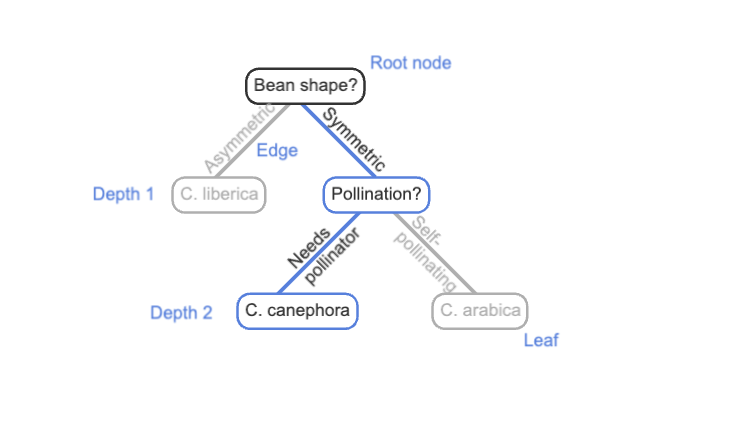

- Root node: "Bean shape?"
- Maximum depth: 2
- Three leaves, each predicting a species

> **[Q]** In the coffee tree above, what is the depth of the leaf "C. liberica"? What about "C. arabica"?

### Decision Tree Classifiers

A **decision tree classifier** is a decision tree built for classification:

- Each **internal node** tests a condition on a single feature
  - Numerical features: an inequality like `sweetness <= 8.2`
  - Categorical features: an equality like `roast == 'dark'`
- Each **leaf** predicts a class (the most common class among training instances that end up in that leaf)

**Key insight:** The decision rules at each node divide the feature space with **axis-aligned hyperplanes** (perpendicular to one feature axis at a time).

### scikit-learn API

Decision tree classifiers are implemented in scikit-learn using `DecisionTreeClassifier()`. For an initialized decision tree classifier, `dtc`:

- `dtc.fit(X, y)` -- trains the model on feature matrix `X` and labels `y`
- `dtc.predict(X)` -- makes predictions for new data
- `dtc.predict_proba(X)` -- estimates the probability that the classification is correct, as the proportion of samples in the resulting leaf that belong to the predicted class
- `dtc.classes_` -- returns the class labels the model learned during `fit`

### Visualizing How a Tree Partitions Feature Space

Let's build a quick example to see how a decision tree splits the feature space compared to our earlier models.

In [2]:
# --- Load Palmer Penguins and prepare a simple 2-feature problem ---
penguins = sns.load_dataset('penguins').dropna()

# Use two features and two species for clear visualization
mask = penguins['species'].isin(['Adelie', 'Gentoo'])
df = penguins.loc[mask, ['bill_length_mm', 'flipper_length_mm', 'species']].copy()
df['species_code'] = LabelEncoder().fit_transform(df['species']) # Adelie=0, Gentoo=1  (Plotting and metrics will be easier with numeric labels)

X = df[['bill_length_mm', 'flipper_length_mm']].values
y = df['species_code'].values
feature_names = ['bill_length_mm', 'flipper_length_mm']
class_names = ['Adelie', 'Gentoo']

print(f'Dataset: {X.shape[0]} penguins, {X.shape[1]} features')
print(f'Classes: {class_names}')
df.head()

Dataset: 265 penguins, 2 features
Classes: ['Adelie', 'Gentoo']


,bill_length_mm,flipper_length_mm,species,species_code
0,39.1,181.0,Adelie,0
1,39.5,186.0,Adelie,0
2,40.3,195.0,Adelie,0
4,36.7,193.0,Adelie,0
5,39.3,190.0,Adelie,0


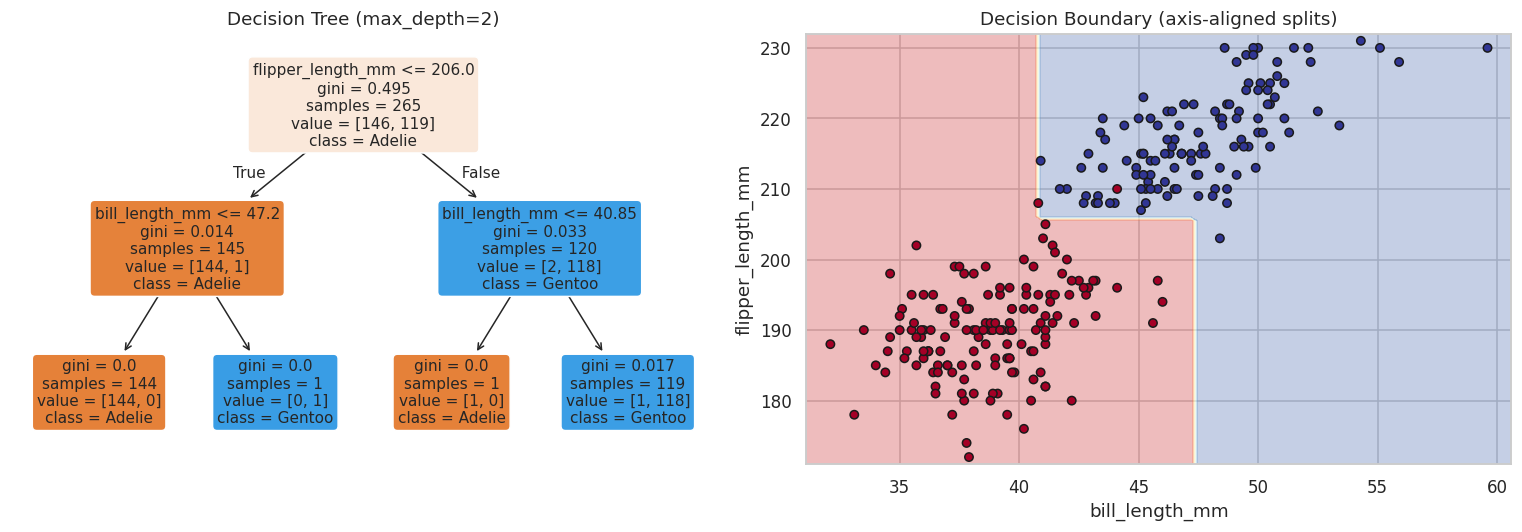

Training accuracy: 0.996


In [3]:
# --- Train a shallow decision tree and visualize ---
dtc = DecisionTreeClassifier(max_depth=2, random_state=42)
dtc.fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: the tree itself
plot_tree(dtc, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=10, ax=axes[0])
axes[0].set_title('Decision Tree (max_depth=2)')

# Right: how it partitions the feature space
DecisionBoundaryDisplay.from_estimator(
    dtc, X, feature_names=feature_names,
    cmap='RdYlBu', alpha=0.3, ax=axes[1]
)
scatter = axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu',
                          edgecolors='k', s=30)
axes[1].set_xlabel('bill_length_mm')
axes[1].set_ylabel('flipper_length_mm')
axes[1].set_title('Decision Boundary (axis-aligned splits)')

plt.tight_layout()
plt.show()

print(f'Training accuracy: {dtc.score(X, y):.3f}')

<div style="background-color: #082e1b; border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px;">

Just extra (programming) note on `DecisionBoundaryDisplay.from_estimator()` which automates the "colored background" behind the scatter plot. Under the hood it creates a dense grid of points across the feature space, calls `predict` on every grid point, and colors each cell by its predicted class. This is much neater than doing it manually as it was the case with the previous notebooks (building a meshgrid with `np.meshgrid`, predicting on every point, then calling `plt.contourf` yourself). One line replaces about ten.
**Without the helper** you would write something like:

```python
xx, yy = np.meshgrid(np.linspace(X[:,0].min(), X[:,0].max(), 200),
                      np.linspace(X[:,1].min(), X[:,1].max(), 200))
Z = dtc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, cmap='RdYlBu', alpha=0.3)
```

`DecisionBoundaryDisplay.from_estimator()` wraps all of this into a single call and handles axis labels, color normalization, and edge cases automatically.

</div>

> **[Q]** Look at the decision boundary plot. How is this different from the boundaries produced by logistic regression or SVM?

### Reading a Decision Tree

scikit-learn also provides a **text representation** of the tree, which is useful for deeper inspection:

In [4]:
# --- Text representation of the tree ---
print(export_text(dtc, feature_names=feature_names))

|--- flipper_length_mm <= 206.00
|   |--- bill_length_mm <= 47.20
|   |   |--- class: 0
|   |--- bill_length_mm >  47.20
|   |   |--- class: 1
|--- flipper_length_mm >  206.00
|   |--- bill_length_mm <= 40.85
|   |   |--- class: 0
|   |--- bill_length_mm >  40.85
|   |   |--- class: 1



> **[Q]** Using the tree above, how would a penguin with `bill_length_mm = 45` and `flipper_length_mm = 210` be classified? Trace it step by step.

---
## Part 2 -- How Trees Are Trained: Impurity and Splitting (Sec. 9.1)

How does the algorithm decide **which feature** to split on and **where** to split?

The goal is to find splits that **separate the classes as cleanly as possible**.

### Purity and Impurity

- A node is **pure** if all its instances belong to one class (purity = 1).
- **Impurity** measures how mixed the classes are at a node.
- The algorithm picks the split that **reduces impurity the most**.

### Two Common Impurity Measures

Let $p_{k,i}$ be the proportion of class $k$ at node $i$:

| Measure | Formula | `criterion=` | Notes |
|---|---|---|---|
| **Gini impurity** | $\sum_k p_{k,i}(1 - p_{k,i})$ | `"gini"` (default) | Max when classes are equally distributed |
| **Entropy** (log loss) | $-\sum_k p_{k,i} \ln(p_{k,i})$ | `"entropy"` | Also max when classes are equal; minus sign keeps it positive |

The **tree's overall impurity** is the weighted average of each leaf's impurity:

$$\text{Tree impurity} = \frac{\sum_i n_i \cdot \text{impurity}_i}{\sum_i n_i}$$

where $n_i$ is the number of instances in leaf $i$.

<div style="background-color: #082e1b; border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px;">

### Quick Example: Purity at a Glance

Use `[Adelie, Gentoo]` to show the class counts at each node. A split is "good" if it moves toward purity:

```
              Root
           [25, 25]        <-- maximally impure (50/50)
           /      \
     Left           Right
    [19, 1]        [6, 24]  <-- both fairly pure, different sizes
```

- **Root** `[25, 25]` -- 50% each class, high impurity.
- **Left child** `[19, 1]` -- 20 samples, 95% Adelie, very low impurity.
- **Right child** `[6, 24]` -- 30 samples, 80% Gentoo, low impurity.

Gini of Left: $0.95 \times 0.05 + 0.05 \times 0.95 = 0.095$

Gini of Right: $0.20 \times 0.80 + 0.80 \times 0.20 = 0.320$

Weighted Gini after split: $\frac{20}{50}(0.095) + \frac{30}{50}(0.320) = 0.038 + 0.192 = 0.230$ (down from 0.500 in the root).

Compare that to a **bad** split that barely helps:

```
              Root
           [25, 25]
           /      \
     Left           Right
    [13, 7]        [12, 18]  <-- still mixed
```

Both children are still impure -- the split did not separate the classes well.

Gini of Left: $0.65 \times 0.35 + 0.35 \times 0.65 = 0.455$

Gini of Right: $0.40 \times 0.60 + 0.60 \times 0.40 = 0.480$

Weighted Gini after split: $\frac{20}{50}(0.455) + \frac{30}{50}(0.480) = 0.182 + 0.288 = 0.470$ (barely changed from 0.500).

</div>

### Worked Example: Computing Gini Impurity

Suppose a node has 30 Adelie and 10 Gentoo penguins (40 total):

$$p_{\text{Adelie}} = \frac{30}{40} = 0.75, \quad p_{\text{Gentoo}} = \frac{10}{40} = 0.25$$

$$\text{Gini} = 0.75 \times (1 - 0.75) + 0.25 \times (1 - 0.25) = 0.1875 + 0.1875 = 0.375$$

A **pure** node (all one class) has Gini = 0. The **worst** case (50/50) has Gini = 0.5.

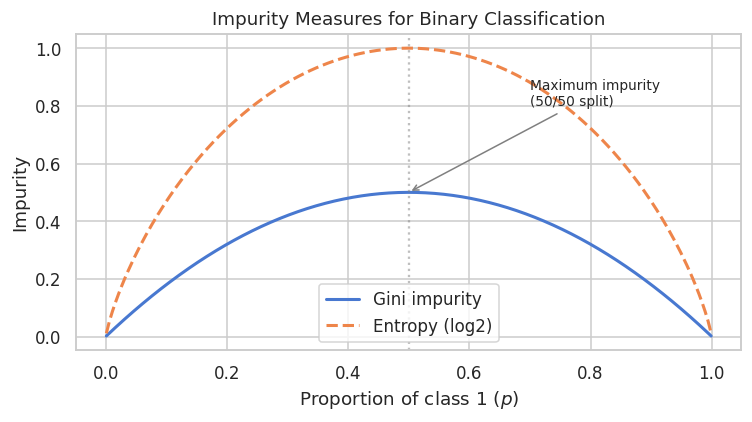

In [5]:
# --- Visualize Gini impurity vs. Entropy for binary classification ---
p = np.linspace(0.001, 0.999, 200)
gini = 2 * p * (1 - p)  # for binary: p*(1-p) + (1-p)*p = 2p(1-p)
entropy = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p, gini, label='Gini impurity', linewidth=2)
ax.plot(p, entropy, label='Entropy (log2)', linewidth=2, linestyle='--')
ax.set_xlabel('Proportion of class 1 ($p$)')
ax.set_ylabel('Impurity')
ax.set_title('Impurity Measures for Binary Classification')
ax.legend()
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.annotate('Maximum impurity\n(50/50 split)', xy=(0.5, 0.5),
            xytext=(0.7, 0.8), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='gray'))
plt.tight_layout()
plt.show()

> **[Q]** Looking at the plot, at what value of $p$ is impurity the highest? Why does this make intuitive sense?

### How Splitting Works: The Greedy Search

At each node, the algorithm:

1. Considers **every feature**
2. For each feature, considers **every possible threshold** (for numerical features) or **every category** (for categorical features)
3. Picks the (feature, threshold) pair that produces the **lowest weighted impurity** in the two resulting child nodes
4. Repeats recursively on each child

This is called **divide-and-conquer** -- a top-down, recursive, **greedy** approach.

<div style="background-color: #082e1b; border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px;">

**What does "greedy" mean?** A greedy algorithm makes the **locally optimal choice at each step** without considering future consequences. At every node, the tree picks the single best split *right now* -- it never backtracks to try a different earlier split that might have led to a better overall tree.

**Contrast with other strategies:**

| Strategy | How it decides | Example |
|---|---|---|
| **Greedy** | Best choice *right now*, no looking ahead | Decision tree splitting |
| **Exhaustive / Brute-force** | Try *every possible* combination, pick the global best | Too expensive for trees (NP-hard) |
| **Dynamic programming** | Break into sub-problems, reuse solutions | Shortest-path algorithms |

**Good analogy to remember:** Imagine driving to a restaurant using only the rule "at every intersection, turn onto whichever road points most directly toward the destination." That is greedy -- fast and usually reasonable, but it might send you into a dead end that a map (global search) would have avoided.

</div>

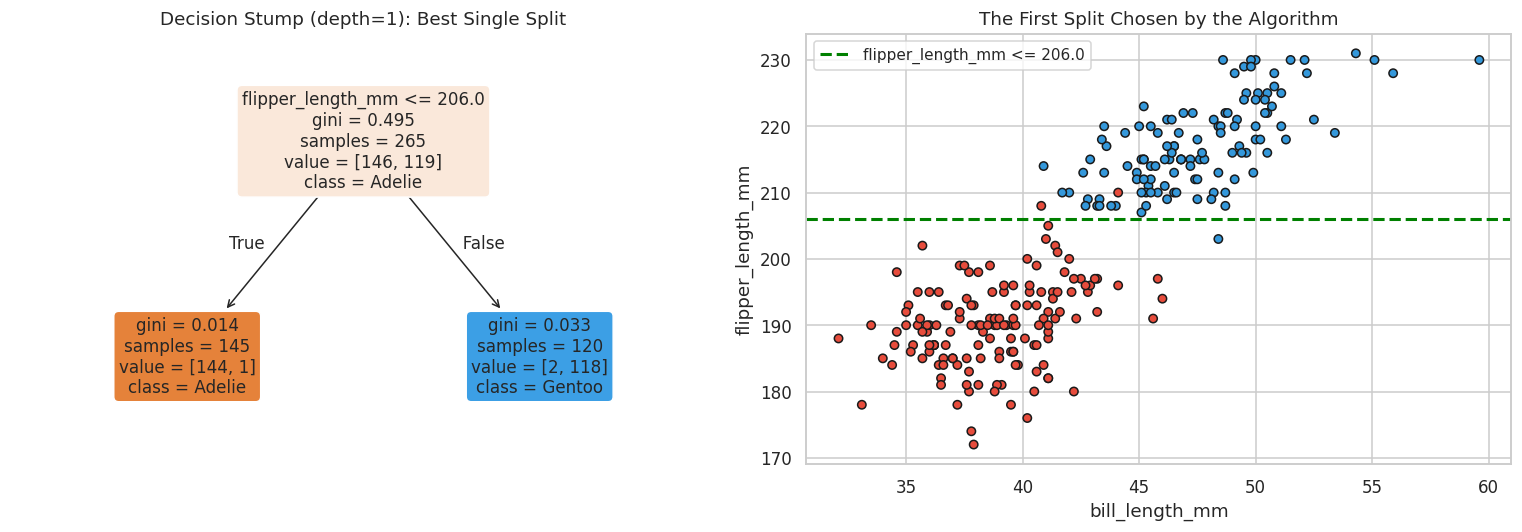

Best first split: flipper_length_mm <= 206.00
Gini impurity at root: 0.4948


In [6]:
# --- Demonstrate: which split does the tree choose first? ---
# Train a depth-1 tree ("decision stump") to see the single best split
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump.fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: the stump
plot_tree(stump, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=11, ax=axes[0])
axes[0].set_title('Decision Stump (depth=1): Best Single Split')

# Right: the data with the split line
colors = ['#e74c3c' if yi == 0 else '#3498db' for yi in y]
axes[1].scatter(X[:, 0], X[:, 1], c=colors, edgecolors='k', s=30)
threshold = stump.tree_.threshold[0]
feat_idx = stump.tree_.feature[0]
if feat_idx == 0:
    axes[1].axvline(threshold, color='green', linewidth=2, linestyle='--',
                    label=f'{feature_names[feat_idx]} <= {threshold:.1f}')
else:
    axes[1].axhline(threshold, color='green', linewidth=2, linestyle='--',
                    label=f'{feature_names[feat_idx]} <= {threshold:.1f}')
axes[1].set_xlabel('bill_length_mm')
axes[1].set_ylabel('flipper_length_mm')
axes[1].set_title('The First Split Chosen by the Algorithm')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

feat_name = feature_names[feat_idx]
print(f'Best first split: {feat_name} <= {threshold:.2f}')
print(f'Gini impurity at root: {stump.tree_.impurity[0]:.4f}')

> **[Q]** Why did the algorithm choose this feature and threshold as the first split? Think about which feature separates the two species more cleanly.

### Exploring Splits: Can You Beat the Algorithm?

The algorithm says the split above is the best. But how do we know? Let's exhaustively evaluate the weighted Gini impurity for **every possible threshold** on **each feature** and see which one truly gives the lowest impurity.

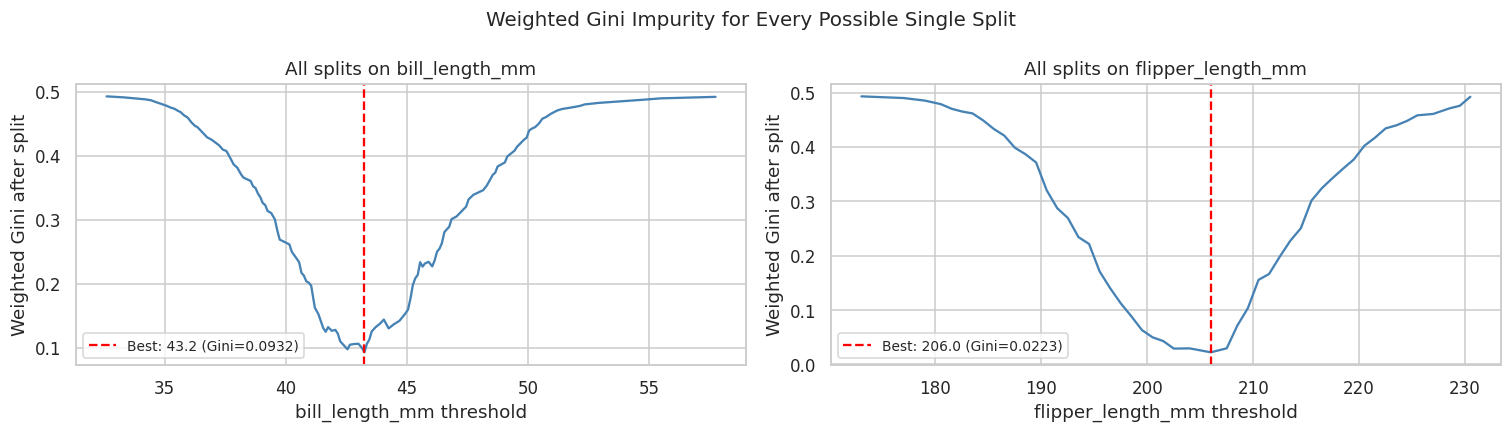

Global best split: flipper_length_mm <= 206.00  (weighted Gini = 0.0223)
Algorithm chose:   flipper_length_mm <= 206.00  (weighted Gini = 0.0223)
They match!


In [7]:
# --- Exhaustive search: weighted Gini for every possible split ---
def weighted_gini(y_left, y_right):
    """Compute weighted Gini impurity after a binary split."""
    def gini(y):
        if len(y) == 0:
            return 0.0
        p = np.mean(y)
        return 2 * p * (1 - p)
    n = len(y_left) + len(y_right)
    return (len(y_left) * gini(y_left) + len(y_right) * gini(y_right)) / n

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

best_gini_overall = 1.0
best_feat_overall = None
best_thresh_overall = None

for fi, fname in enumerate(feature_names):
    vals = np.sort(np.unique(X[:, fi]))
    # midpoints between consecutive unique values (same as CART)
    thresholds = (vals[:-1] + vals[1:]) / 2
    ginis = []
    for t in thresholds:
        left_mask = X[:, fi] <= t
        g = weighted_gini(y[left_mask], y[~left_mask])
        ginis.append(g)
    ginis = np.array(ginis)

    # track overall best
    local_best_idx = np.argmin(ginis)
    if ginis[local_best_idx] < best_gini_overall:
        best_gini_overall = ginis[local_best_idx]
        best_feat_overall = fi
        best_thresh_overall = thresholds[local_best_idx]

    axes[fi].plot(thresholds, ginis, linewidth=1.5, color='steelblue')
    axes[fi].axvline(thresholds[local_best_idx], color='red', linestyle='--',
                     label=f'Best: {thresholds[local_best_idx]:.1f} '
                           f'(Gini={ginis[local_best_idx]:.4f})')
    axes[fi].set_xlabel(f'{fname} threshold')
    axes[fi].set_ylabel('Weighted Gini after split')
    axes[fi].set_title(f'All splits on {fname}')
    axes[fi].legend(fontsize=9)

plt.suptitle('Weighted Gini Impurity for Every Possible Single Split', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Global best split: {feature_names[best_feat_overall]} '
      f'<= {best_thresh_overall:.2f}  '
      f'(weighted Gini = {best_gini_overall:.4f})')
print(f'Algorithm chose:   {feature_names[stump.tree_.feature[0]]} '
      f'<= {stump.tree_.threshold[0]:.2f}  '
      f'(weighted Gini = {best_gini_overall:.4f})')
print('They match!')

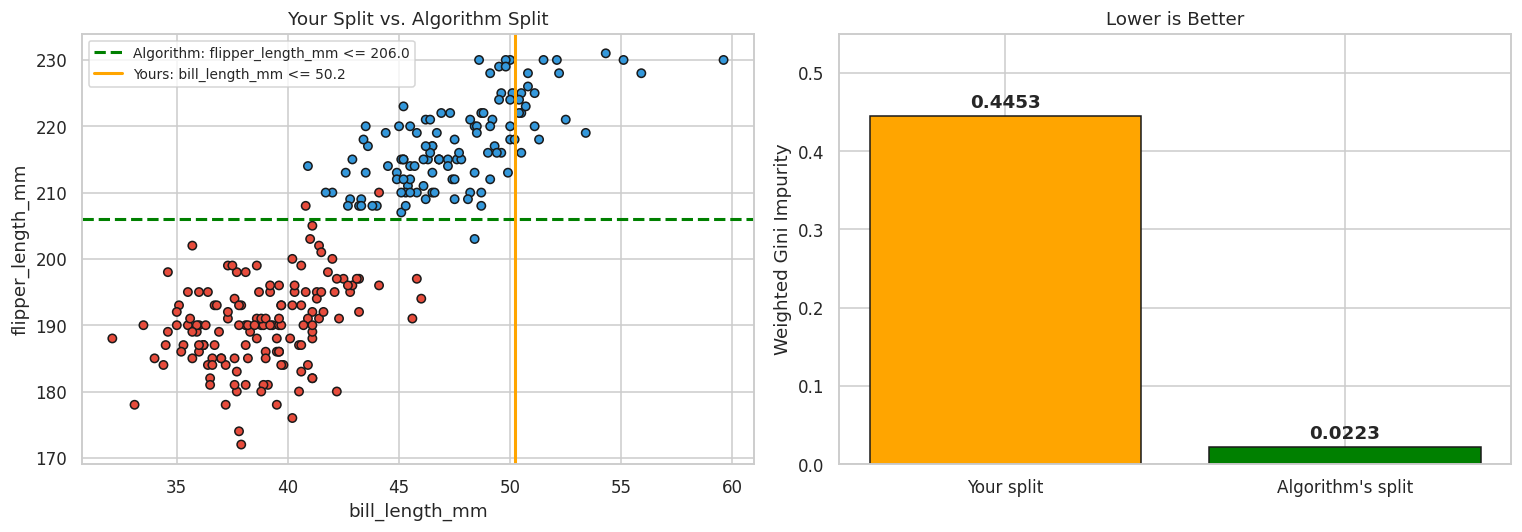

Your split:  bill_length_mm <= 50.2
  Left:  245 samples (40.41% Gentoo)
  Right: 20 samples (100.00% Gentoo)
  Weighted Gini = 0.4453

>> Algorithm wins by 0.4229 Gini.


In [8]:
# ============================================================
# TRY YOUR OWN SPLIT -- change these two values and re-run!
# ============================================================
try_feature = 'bill_length_mm'   # 'bill_length_mm' or 'flipper_length_mm'
try_threshold = 50.2               # pick any value in the feature's range
# ============================================================

fi_try = feature_names.index(try_feature)
left_mask = X[:, fi_try] <= try_threshold
gini_try = weighted_gini(y[left_mask], y[~left_mask])

# --- Plot: data with your split vs. algorithm's split ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: scatter with both split lines
colors = ['#e74c3c' if yi == 0 else '#3498db' for yi in y]
axes[0].scatter(X[:, 0], X[:, 1], c=colors, edgecolors='k', s=30)

# Algorithm's best split
algo_fi = stump.tree_.feature[0]
algo_t = stump.tree_.threshold[0]
if algo_fi == 0:
    axes[0].axvline(algo_t, color='green', linewidth=2, linestyle='--',
                    label=f'Algorithm: {feature_names[algo_fi]} <= {algo_t:.1f}')
else:
    axes[0].axhline(algo_t, color='green', linewidth=2, linestyle='--',
                    label=f'Algorithm: {feature_names[algo_fi]} <= {algo_t:.1f}')

# Your split
if fi_try == 0:
    axes[0].axvline(try_threshold, color='orange', linewidth=2, linestyle='-',
                    label=f'Yours: {try_feature} <= {try_threshold:.1f}')
else:
    axes[0].axhline(try_threshold, color='orange', linewidth=2, linestyle='-',
                    label=f'Yours: {try_feature} <= {try_threshold:.1f}')

axes[0].set_xlabel('bill_length_mm')
axes[0].set_ylabel('flipper_length_mm')
axes[0].set_title('Your Split vs. Algorithm Split')
axes[0].legend(fontsize=9)

# Right panel: bar comparison
algo_gini = weighted_gini(y[X[:, algo_fi] <= algo_t],
                          y[X[:, algo_fi] > algo_t])
bar_colors = ['orange', 'green']
bars = axes[1].bar(['Your split', "Algorithm's split"],
                   [gini_try, algo_gini], color=bar_colors, edgecolor='k')
axes[1].set_ylabel('Weighted Gini Impurity')
axes[1].set_title('Lower is Better')
axes[1].set_ylim(0, 0.55)
for bar, val in zip(bars, [gini_try, algo_gini]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

n_left = left_mask.sum()
n_right = (~left_mask).sum()
print(f'Your split:  {try_feature} <= {try_threshold}')
print(f'  Left:  {n_left} samples ({np.mean(y[left_mask]):.2%} Gentoo)')
print(f'  Right: {n_right} samples ({np.mean(y[~left_mask]):.2%} Gentoo)')
print(f'  Weighted Gini = {gini_try:.4f}')
print()
if gini_try <= algo_gini:
    print('>> Your split ties or beats the algorithm!')
else:
    print(f'>> Algorithm wins by {gini_try - algo_gini:.4f} Gini.')

---
## Part 3 -- Decision Tree Algorithms: ID3, C5.0, CART (Sec. 9.2)

The divide-and-conquer approach has been implemented in several algorithms over the decades:

| Algorithm | Year | Model Type | Input Features | Impurity | Pruning | Available in `scikit-learn` |
|---|---|---|---|---|---|---|
| **ID3** | 1986 | Classification | Categorical only | Entropy | No | No |
| **C4.5 / C5.0** | 1993 / 2011 | Classification | Categorical + Numerical | Entropy | Yes | No |
| **CART** | 1984 | Classification + Regression | Categorical + Numerical | Gini / MSE | Yes | **Yes** |

### Key Differences

- **ID3**: The simplest. Works only with categorical features, uses entropy, no pruning. Each feature can only be used once per path. Splits are **multiway** (one branch per category).

- **C5.0**: Evolution of ID3. Handles numerical features, supports pruning, converts trees to rulesets, supports boosting and winnowing (feature selection). Not in `scikit-learn` but available in R.

- **CART**: The workhorse. Handles both classification and regression. Always makes **binary splits** (even for categorical features). Uses Gini impurity for classification, MSE for regression. Supports cost-complexity pruning. **This is what `scikit-learn` implements.**

> **[Q]** A researcher has a dataset with both numerical features (age, blood pressure) and a categorical feature (smoker: yes/no). They want to predict whether a patient has heart disease. Which algorithm(s) from the table could they use?

### Greedy Algorithms

All three algorithms are **greedy** -- they pick the locally best split at each step without looking ahead.

- **Advantage**: fast and practical
- **Disadvantage**: not guaranteed to find the globally optimal tree

Finding the truly optimal decision tree is NP-hard, so greedy is the practical choice.

---
## Part 4 -- Classification Trees in scikit-learn

Let's build a proper classification tree pipeline with a train/test split, using all three penguin species.

In [9]:
# --- Prepare the full Palmer Penguins dataset ---
penguins_full = sns.load_dataset('penguins').dropna()

feature_cols = ['bill_length_mm', 'bill_depth_mm',
                'flipper_length_mm', 'body_mass_g']
X_full = penguins_full[feature_cols].values
y_full = penguins_full['species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.25, random_state=42, stratify=y_full
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Classes:      {np.unique(y_full)}')

Training set: 249 samples
Test set:     84 samples
Classes:      ['Adelie' 'Chinstrap' 'Gentoo']


In [10]:
# --- Train a decision tree (no restrictions) ---
dtc_full = DecisionTreeClassifier(random_state=42)
dtc_full.fit(X_train, y_train)

y_pred = dtc_full.predict(X_test)

print(f'Training accuracy: {dtc_full.score(X_train, y_train):.3f}')
print(f'Test accuracy:     {accuracy_score(y_test, y_pred):.3f}')
print(f'Tree depth:        {dtc_full.get_depth()}')
print(f'Number of leaves:  {dtc_full.get_n_leaves()}')

Training accuracy: 1.000
Test accuracy:     0.964
Tree depth:        5
Number of leaves:  11


> **[Q]** The training accuracy is 1.000 (perfect). Is that a good sign or a warning sign?

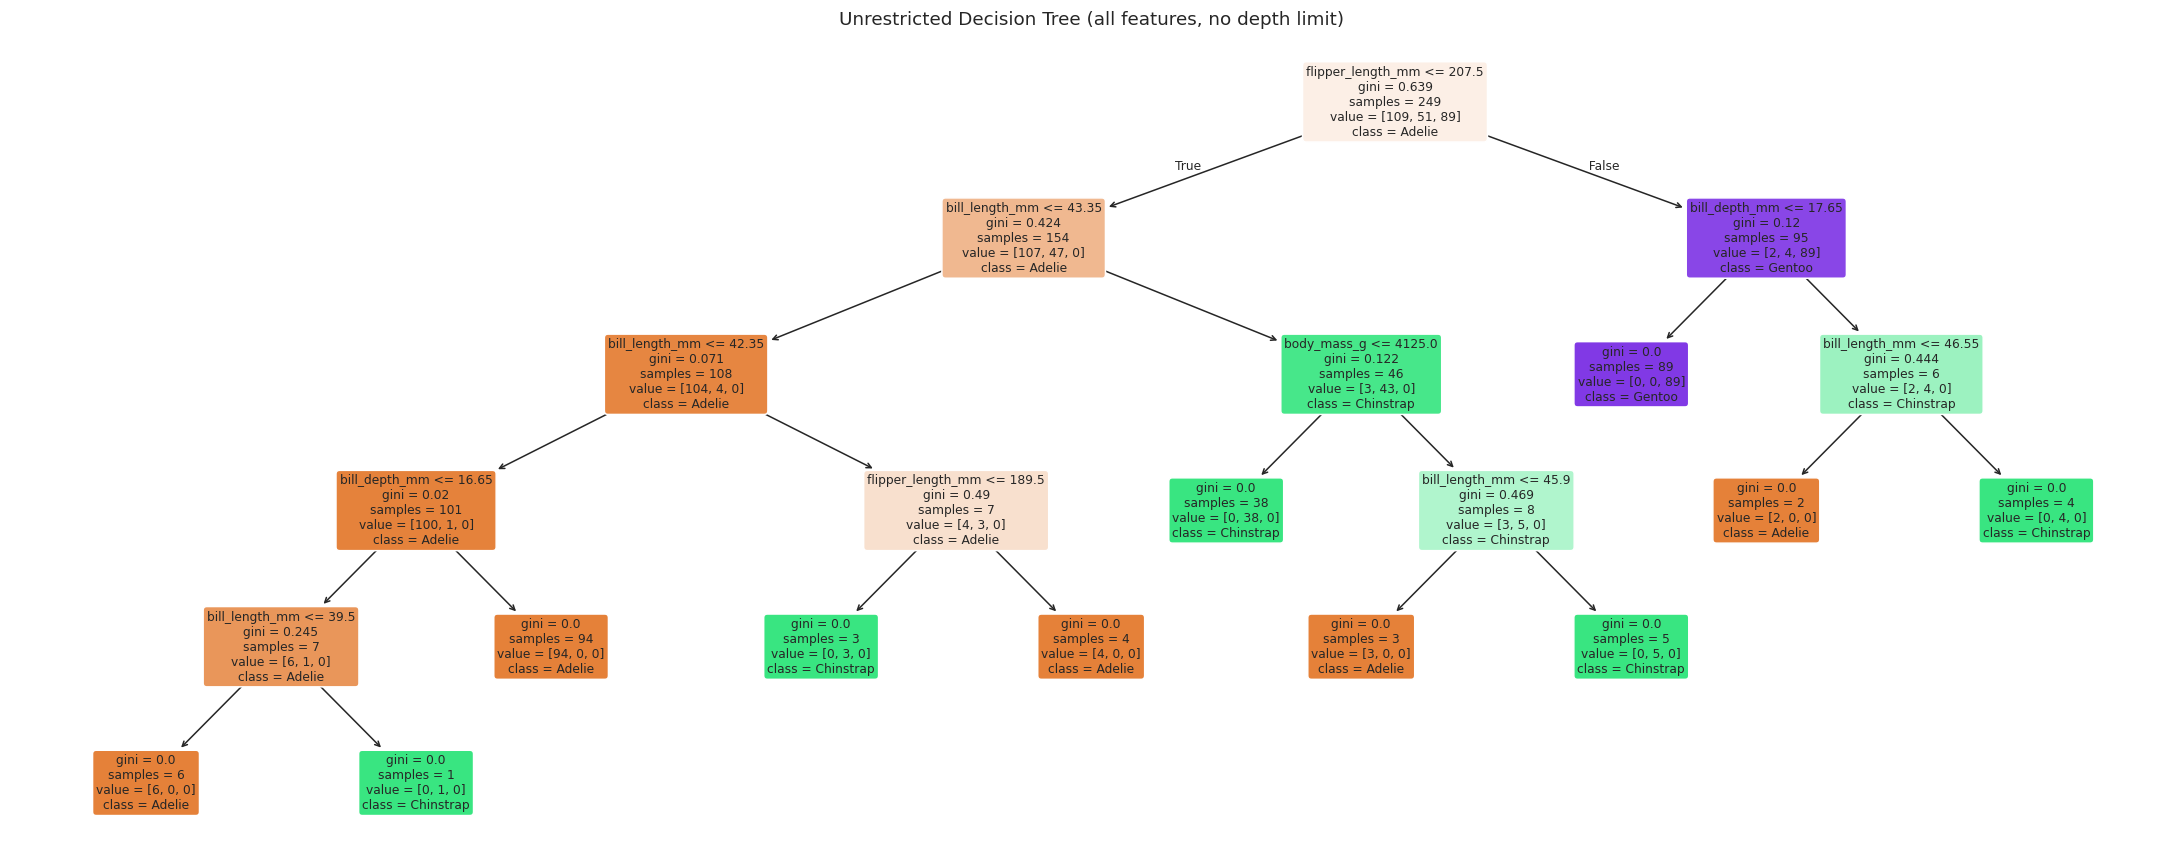

In [11]:
# --- Visualize the full tree ---
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dtc_full, feature_names=feature_cols,
          class_names=list(np.unique(y_full)),
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Unrestricted Decision Tree (all features, no depth limit)')
plt.tight_layout()
plt.show()

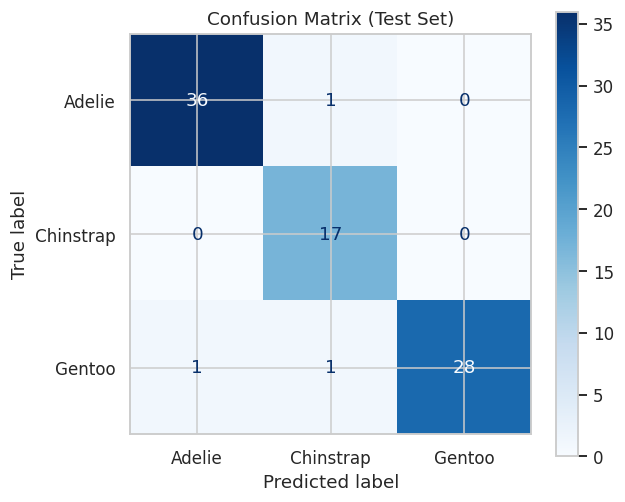

In [12]:
# --- Confusion matrix ---
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=np.unique(y_full),
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

### Feature Importance

One advantage of decision trees: they naturally rank features by importance. A feature's importance is based on how much it reduces impurity across all splits that use it.

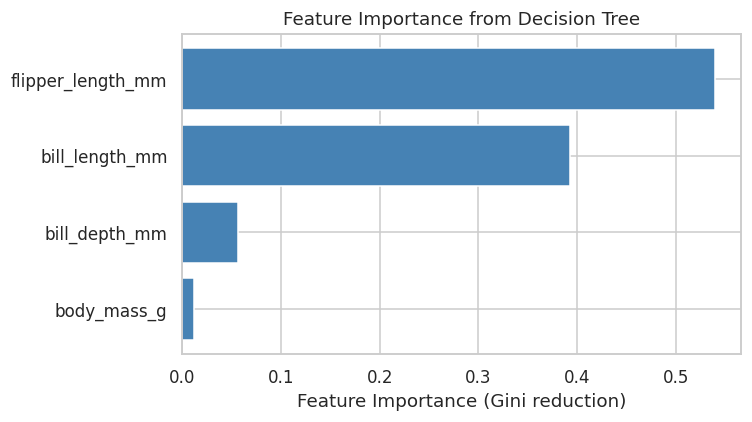

In [13]:
# --- Feature importance ---
importances = dtc_full.feature_importances_
sorted_idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(range(len(importances)), importances[sorted_idx], color='steelblue')
ax.set_yticks(range(len(importances)))
ax.set_yticklabels(np.array(feature_cols)[sorted_idx])
ax.set_xlabel('Feature Importance (Gini reduction)')
ax.set_title('Feature Importance from Decision Tree')
plt.tight_layout()
plt.show()

> **[Q]** Which feature is most important for classifying penguin species? Does this match your intuition from looking at the tree?

### Prediction Probabilities

`predict_proba()` gives the proportion of each class in the leaf where the instance lands:

In [14]:
# --- Prediction probabilities for first few test instances ---
probs = dtc_full.predict_proba(X_test[:5])
prob_df = pd.DataFrame(probs, columns=dtc_full.classes_)
prob_df['Predicted'] = y_pred[:5]
prob_df['Actual'] = y_test[:5]
print(prob_df.to_string(index=False))

 Adelie  Chinstrap  Gentoo Predicted    Actual
    0.0        1.0     0.0 Chinstrap Chinstrap
    0.0        0.0     1.0    Gentoo    Gentoo
    1.0        0.0     0.0    Adelie    Adelie
    0.0        0.0     1.0    Gentoo    Gentoo
    0.0        1.0     0.0 Chinstrap Chinstrap


---
## Part 5 -- Controlling Tree Growth: Early Stopping and Pruning

An unrestricted tree will grow until every leaf is pure -- that means **overfitting**. Two strategies to prevent this:

### Strategy 1: Early Stopping (Pre-Pruning)

Stop growing the tree before it gets too deep.

| Parameter | Default | What it does |
|---|---|---|
| `max_depth` | `None` | Maximum depth of any leaf |
| `min_samples_split` | 2 | Minimum instances needed at a node to attempt a split |
| `min_samples_leaf` | 1 | Minimum instances required in each resulting leaf |
| `max_leaf_nodes` | `None` | Maximum total number of leaves |

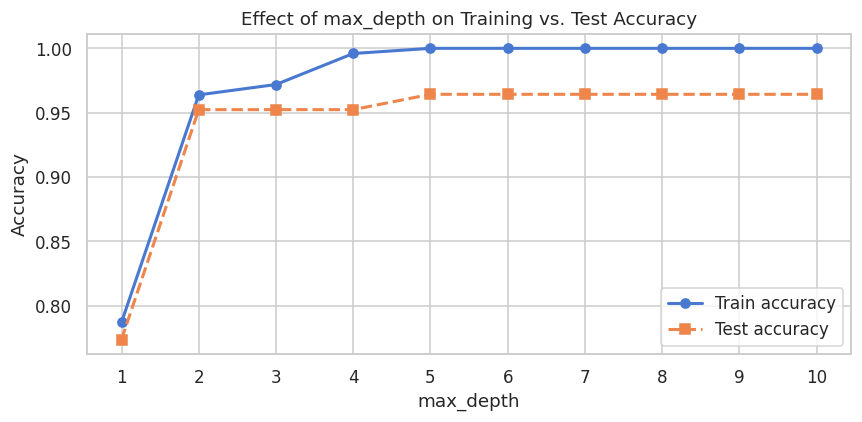

In [15]:
# --- Effect of max_depth on performance ---
depths = range(1, 11)
train_scores = []
test_scores = []

for d in depths:
    dtc_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    dtc_d.fit(X_train, y_train)
    train_scores.append(dtc_d.score(X_train, y_train))
    test_scores.append(dtc_d.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depths, train_scores, 'o-', label='Train accuracy', linewidth=2)
ax.plot(depths, test_scores, 's--', label='Test accuracy', linewidth=2)
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Effect of max_depth on Training vs. Test Accuracy')
ax.legend()
ax.set_xticks(list(depths))
plt.tight_layout()
plt.show()

> **[Q]** At what depth does the test accuracy plateau? What happens to the training accuracy as depth increases? What does this tell us about overfitting?

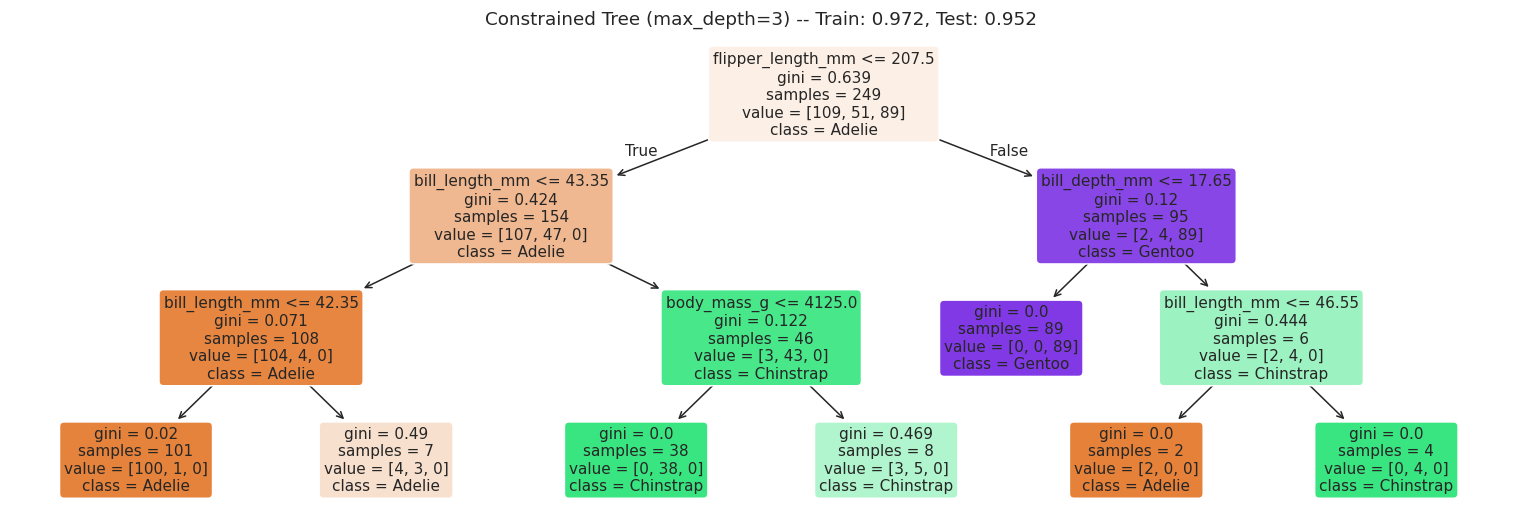

In [16]:
# --- Compare: constrained tree vs unconstrained ---
dtc_constrained = DecisionTreeClassifier(max_depth=3, random_state=42)
dtc_constrained.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(14, 5))
plot_tree(dtc_constrained, feature_names=feature_cols,
          class_names=list(np.unique(y_full)),
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title(f'Constrained Tree (max_depth=3) -- '
             f'Train: {dtc_constrained.score(X_train, y_train):.3f}, '
             f'Test: {dtc_constrained.score(X_test, y_test):.3f}')
plt.tight_layout()
plt.show()

### Strategy 2: Cost-Complexity Pruning (Post-Pruning)

Grow the full tree first, then **prune** decision nodes whose subtree does not justify its complexity.

The **cost-complexity** of a tree $T$ is:

$$R_\alpha(T) = R(T) + \alpha \cdot |\tilde{T}|$$

where:
- $R(T)$ = weighted impurity of the tree (how many misclassifications it makes)
- $|\tilde{T}|$ = number of leaves (how complex the tree is)
- $\alpha$ = penalty per leaf (controls the tradeoff -- higher $\alpha$ penalizes complexity more)

<div style="background-color: #082e1b; border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px;">

**Intuition:** Think of $R_\alpha(T)$ as a "total cost" that balances two competing goals:

- **Low error** -- $R(T)$ wants the tree to be accurate (more leaves = more specific rules = lower error)
- **Low complexity** -- $\alpha \cdot |\tilde{T}|$ punishes having too many leaves

When $\alpha = 0$: there is no penalty for complexity, so the full tree wins (lowest error).
When $\alpha$ is large: each extra leaf is very expensive, so only a small tree (or even a single-node stump) survives.

</div>

For each decision node $t$, the algorithm asks:

> *"Is the subtree below $t$ worth its complexity, or would a single leaf be cheaper?"*

so, it compares:
- $R_\alpha(t)$ = cost if we **collapse** $t$'s subtree into a single leaf (higher error, but fewer leaves)
- $R_\alpha(T_t)$ = cost if we **keep** the subtree (lower error, but more leaves to pay for)

If the single leaf is cheaper (or equal), the subtree is **pruned**.

<div style="background-color: #082e1b; border-left: 4px solid #6366f1; padding: 14px 18px; margin: 16px 0; border-radius: 6px;">

**Concrete example:** Suppose a subtree has 3 leaves and reduces impurity by 0.02 compared to collapsing it into one leaf. If $\alpha = 0.005$, keeping the subtree costs $0.005 \times 3 = 0.015$ in complexity penalty, which is less than the 0.02 impurity gain -- so we keep it. But if $\alpha = 0.01$, the penalty is $0.01 \times 3 = 0.03$, which exceeds the 0.02 gain -- so we prune it.

</div>

In scikit-learn: set `ccp_alpha` to a positive value. The algorithm tries many $\alpha$ values and finds all the "critical" points where a subtree gets pruned.

In [17]:
# --- Find the effective alphas via cost-complexity pruning path ---
path = dtc_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f'Number of alpha values explored: {len(ccp_alphas)}')
print(f'Alpha range: {ccp_alphas[0]:.5f} to {ccp_alphas[-1]:.5f}')

Number of alpha values explored: 8
Alpha range: 0.00000 to 0.33055


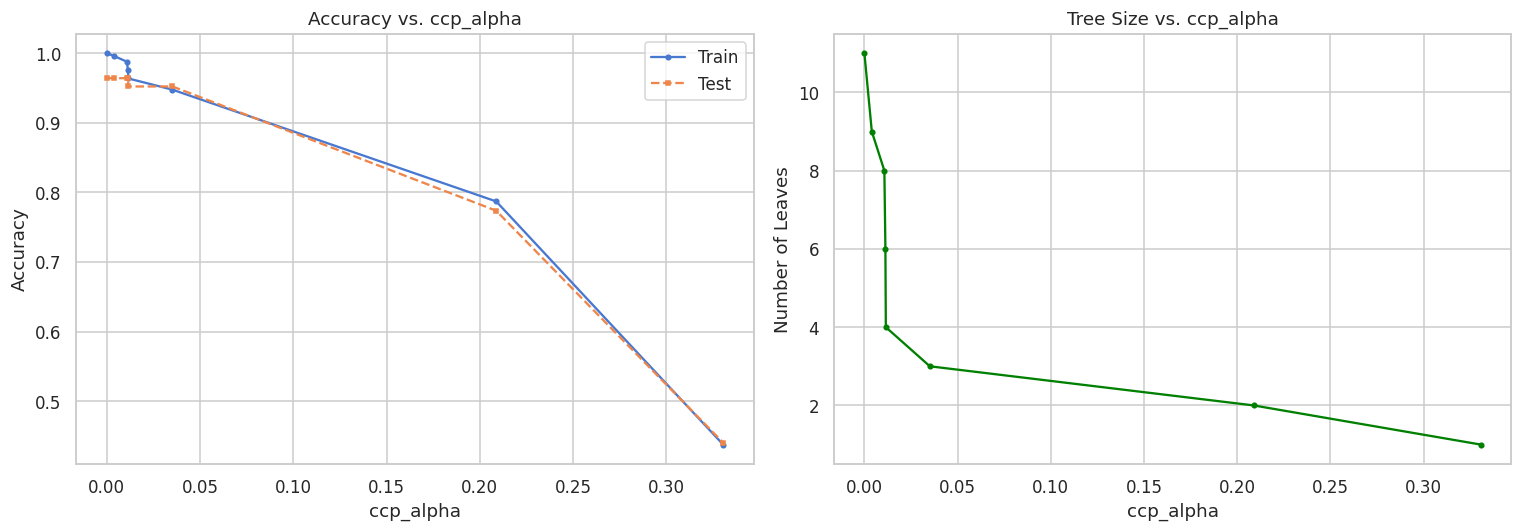

Best alpha: 0.00000
Test accuracy at best alpha: 0.964
Number of leaves at best alpha: 11


In [18]:
# --- Train trees for each alpha and track performance ---
train_acc = []
test_acc = []
n_leaves = []

for alpha in ccp_alphas:
    dtc_a = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    dtc_a.fit(X_train, y_train)
    train_acc.append(dtc_a.score(X_train, y_train))
    test_acc.append(dtc_a.score(X_test, y_test))
    n_leaves.append(dtc_a.get_n_leaves())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: accuracy vs alpha
axes[0].plot(ccp_alphas, train_acc, 'o-', label='Train', markersize=3)
axes[0].plot(ccp_alphas, test_acc, 's--', label='Test', markersize=3)
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs. ccp_alpha')
axes[0].legend()

# Right: number of leaves vs alpha
axes[1].plot(ccp_alphas, n_leaves, 'o-', color='green', markersize=3)
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Number of Leaves')
axes[1].set_title('Tree Size vs. ccp_alpha')

plt.tight_layout()
plt.show()

# Find the alpha with best test accuracy
best_idx = np.argmax(test_acc)
print(f'Best alpha: {ccp_alphas[best_idx]:.5f}')
print(f'Test accuracy at best alpha: {test_acc[best_idx]:.3f}')
print(f'Number of leaves at best alpha: {n_leaves[best_idx]}')

> **[Q]** What happens to the tree as `ccp_alpha` increases? Why does test accuracy eventually drop?

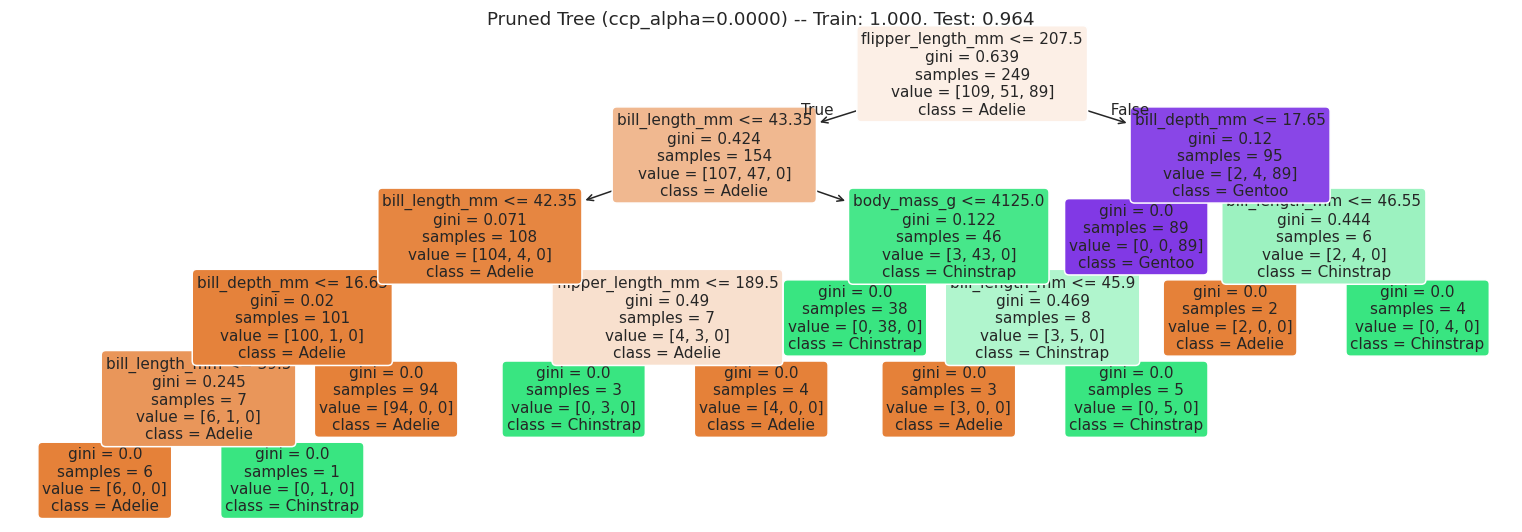

In [19]:
# --- Visualize the pruned tree at the best alpha ---
dtc_pruned = DecisionTreeClassifier(ccp_alpha=ccp_alphas[best_idx],
                                    random_state=42)
dtc_pruned.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(14, 5))
plot_tree(dtc_pruned, feature_names=feature_cols,
          class_names=list(np.unique(y_full)),
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title(f'Pruned Tree (ccp_alpha={ccp_alphas[best_idx]:.4f}) -- '
             f'Train: {dtc_pruned.score(X_train, y_train):.3f}, '
             f'Test: {dtc_pruned.score(X_test, y_test):.3f}')
plt.tight_layout()
plt.show()

---
## Part 6 -- Decision Trees for Regression (Sec. 9.3)

Decision trees are not just for classification -- they can also do **regression**.

### How They Differ from Classification Trees

| Classification Tree | Regression Tree |
|---|---|
| Leaf predicts the **most common class** | Leaf predicts the **mean** (or median) of the target |
| Split criterion: **Gini impurity** or **entropy** | Split criterion: **MSE**, MAE, or Friedman's improvement |
| Output: class labels | Output: continuous values |

The training process is the same divide-and-conquer approach: find the split that minimizes the error measure.

**Key difference from linear regression**: A regression tree produces a **piecewise-constant** prediction (a step function), not a smooth line.

### Visualizing Piecewise-Constant Predictions (1D)

To see how a regression tree works, let's start with a simple **1D problem**: 80 noisy points sampled from a sine curve. We train three regression trees at depths 1, 3, and 10 and overlay the predictions.

Because each leaf predicts a single constant (the mean of its training points), the output is a **step function** -- flat segments that jump at each split threshold. Deeper trees have more splits, so more steps, approximating the curve more closely but also fitting the noise.

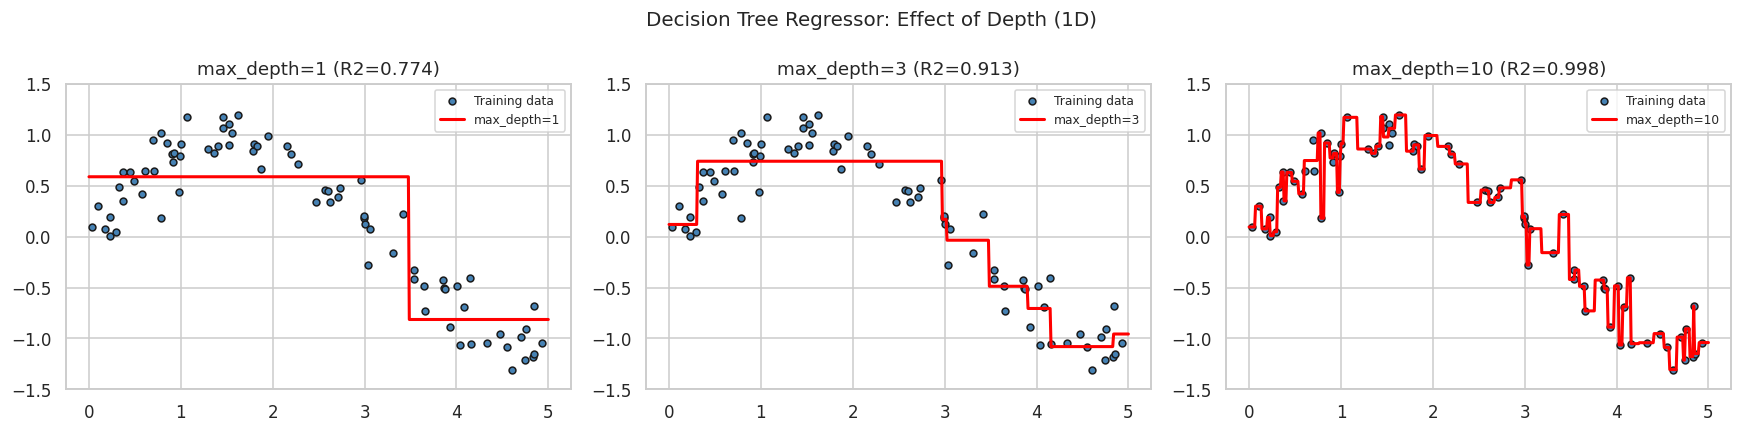

In [20]:
# --- Regression tree: simple 1D example to see the step function ---
np.random.seed(42)
X_reg = np.sort(5 * np.random.rand(80, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + 0.2 * np.random.randn(80)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, depth in enumerate([1, 3, 10]):
    dtr = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dtr.fit(X_reg, y_reg)

    X_plot = np.linspace(0, 5, 500).reshape(-1, 1)
    y_plot = dtr.predict(X_plot)

    axes[i].scatter(X_reg, y_reg, s=20, edgecolor='k',
                    color='steelblue', label='Training data')
    axes[i].plot(X_plot, y_plot, color='red', linewidth=2,
                label=f'max_depth={depth}')
    axes[i].set_title(f'max_depth={depth} (R2={dtr.score(X_reg, y_reg):.3f})')
    axes[i].legend(fontsize=8)
    axes[i].set_ylim(-1.5, 1.5)

plt.suptitle('Decision Tree Regressor: Effect of Depth (1D)', fontsize=13)
plt.tight_layout()
plt.show()

> **[Q]** Compare the three plots. Which depth do you think gives the best generalization to new data? Why?

### Regression Tree on Real Data: Predicting Penguin Body Mass

Now let's apply `DecisionTreeRegressor` to real data. We will predict `body_mass_g` from three bill/flipper measurements.

The workflow mirrors classification:
1. Split into train/test
2. Train trees at several depths and compare **R-squared** ($R^2$) and **RMSE** on both sets
3. Visualize the best tree
4. Check an **Actual vs. Predicted** scatter plot to assess quality

In [21]:
# --- Regression tree: predict body_mass_g from other features ---
reg_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
X_reg_full = penguins_full[reg_features].values
y_reg_full = penguins_full['body_mass_g'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_reg_full, y_reg_full, test_size=0.25, random_state=42
)

# Train with different depths
results = []
for d in [2, 4, 6, None]:
    dtr = DecisionTreeRegressor(max_depth=d, random_state=42)
    dtr.fit(X_tr, y_tr)
    y_pred_tr = dtr.predict(X_tr)
    y_pred_te = dtr.predict(X_te)
    results.append({
        'max_depth': str(d) if d else 'None',
        'n_leaves': dtr.get_n_leaves(),
        'Train R2': f'{r2_score(y_tr, y_pred_tr):.3f}',
        'Test R2': f'{r2_score(y_te, y_pred_te):.3f}',
        'Train RMSE': f'{np.sqrt(mean_squared_error(y_tr, y_pred_tr)):.0f}',
        'Test RMSE': f'{np.sqrt(mean_squared_error(y_te, y_pred_te)):.0f}',
    })

pd.DataFrame(results)

,max_depth,n_leaves,Train R2,Test R2,Train RMSE,Test RMSE
0,2,4,0.779,0.769,382,374
1,4,16,0.874,0.785,288,361
2,6,55,0.926,0.755,221,385
3,None,236,1.000,0.695,0,430


Based on the table, `max_depth=4` gives a good balance between train and test $R^2$. Let's visualize that tree. Notice that each **leaf now shows a predicted value** (the mean of the training targets in that region) instead of a class label. The `value` field in each node is the mean target, and `squared_error` replaces Gini as the split criterion.

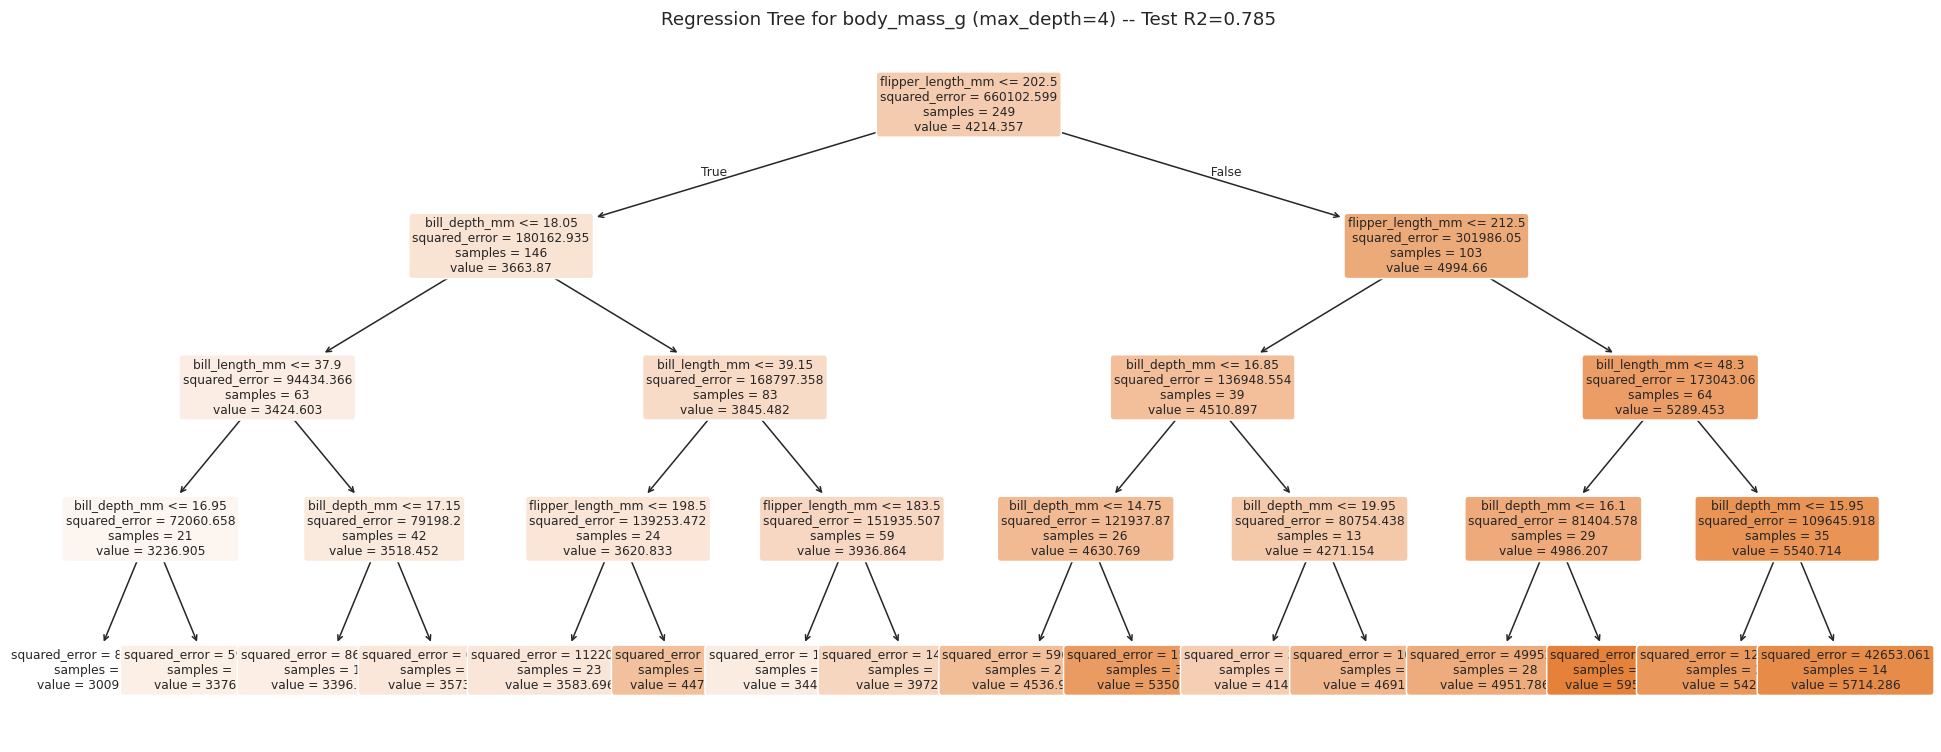

In [22]:
# --- Visualize the depth-4 regression tree ---
dtr_best = DecisionTreeRegressor(max_depth=4, random_state=42)
dtr_best.fit(X_tr, y_tr)

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(dtr_best, feature_names=reg_features,
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title(f'Regression Tree for body_mass_g (max_depth=4) -- '
             f'Test R2={r2_score(y_te, dtr_best.predict(X_te)):.3f}')
plt.tight_layout()
plt.show()

A useful diagnostic for regression models is the **Actual vs. Predicted** scatter plot. If predictions were perfect, every point would fall on the red diagonal ($y = \hat{y}$). Points far from the line are large errors. Notice the **horizontal banding** -- that is the piecewise-constant nature of the tree: all instances in the same leaf get the exact same prediction.

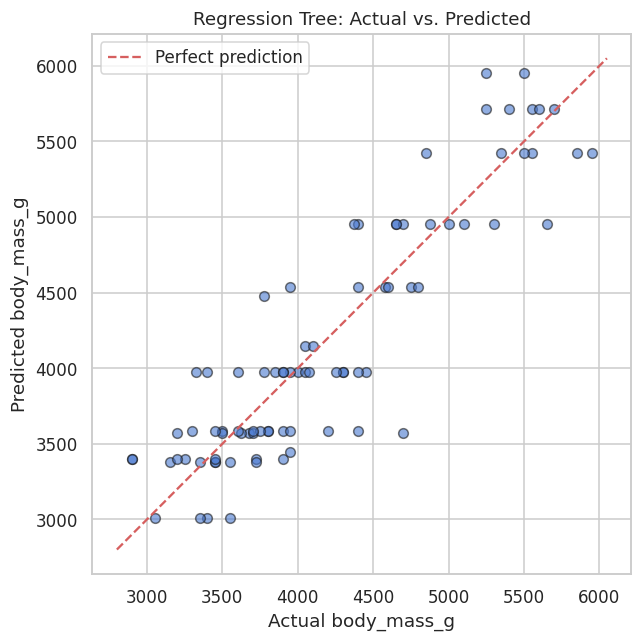

In [23]:
# --- Actual vs. Predicted plot ---
y_pred_best = dtr_best.predict(X_te)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_te, y_pred_best, alpha=0.6, edgecolors='k', s=40)
lims = [min(y_te.min(), y_pred_best.min()) - 100,
        max(y_te.max(), y_pred_best.max()) + 100]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual body_mass_g')
ax.set_ylabel('Predicted body_mass_g')
ax.set_title('Regression Tree: Actual vs. Predicted')
ax.legend()
plt.tight_layout()
plt.show()

> **[Q]** Why do the predicted values in the "Actual vs. Predicted" plot form horizontal bands?

### `DecisionTreeRegressor()` Key Parameters

| Parameter | Default | Description |
|---|---|---|
| `criterion` | `"squared_error"` | Error metric for splits (also `"friedman_mse"`, `"absolute_error"`, `"poisson"`) |
| `max_depth` | `None` | Maximum depth of any leaf |
| `max_leaf_nodes` | `None` | Maximum number of leaves |
| `min_samples_split` | 2 | Minimum instances at a node to attempt a split |
| `ccp_alpha` | 0.0 | Cost-complexity pruning parameter |

Same early stopping and pruning parameters as the classifier -- just different splitting criteria.

---
## Wrap-Up: Advantages, Disadvantages, and What is Next

### Decision Tree Pros and Cons

| Advantages | Disadvantages |
|---|---|
| Highly interpretable (flowchart-like) | Large trees become hard to interpret |
| Can be translated to if/else rules | Axis-aligned splits only -- correlated features create deep, staircase-like boundaries |
| No feature scaling needed | Prone to overfitting without constraints |
| Handles both classification and regression | Very sensitive to training data -- adding one instance can produce a completely different tree |
| Feature importance is built in | Greedy algorithm is not guaranteed to find the optimal tree |

### Sensitivity to Data

A single decision tree is **unstable**: small changes in the training data can lead to a very different tree. This is one of the biggest practical drawbacks.

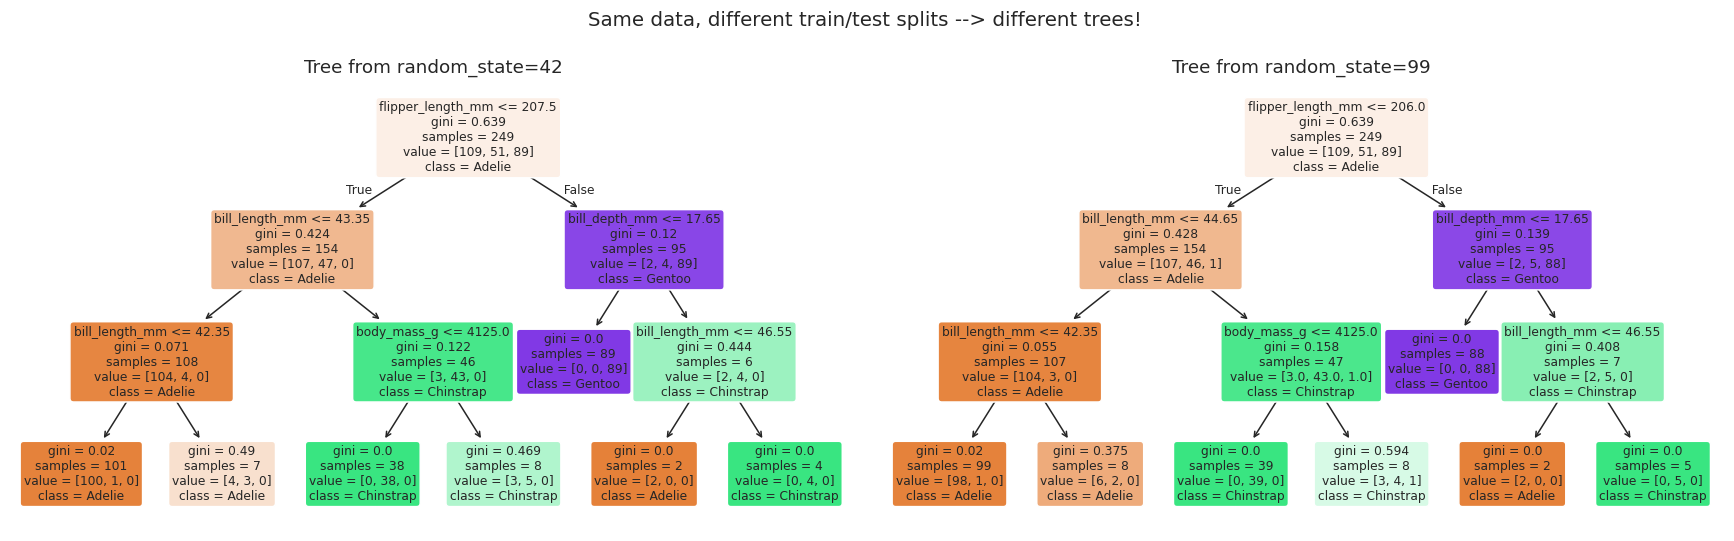

In [24]:
# --- Demonstrate sensitivity: two trees from slightly different data ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, rs in enumerate([42, 99]):
    X_tr_i, _, y_tr_i, _ = train_test_split(
        X_full, y_full, test_size=0.25, random_state=rs, stratify=y_full
    )
    dtc_i = DecisionTreeClassifier(max_depth=3, random_state=42)
    dtc_i.fit(X_tr_i, y_tr_i)
    plot_tree(dtc_i, feature_names=feature_cols,
             class_names=list(np.unique(y_full)),
             filled=True, rounded=True, fontsize=8, ax=axes[i])
    axes[i].set_title(f'Tree from random_state={rs}')

plt.suptitle('Same data, different train/test splits --> different trees!',
             fontsize=13)
plt.tight_layout()
plt.show()

### Summary

| Topic | Key Takeaway |
|---|---|
| Structure | Tree of yes/no questions; leaves give predictions |
| Training | Greedy divide-and-conquer; split on feature/threshold that minimizes impurity |
| Impurity | Gini (default) or Entropy for classification; MSE for regression |
| Algorithms | CART (scikit-learn) handles both classification and regression with binary splits |
| Overfitting control | Early stopping (`max_depth`, `min_samples_leaf`, ...) or cost-complexity pruning (`ccp_alpha`) |
| Regression | Same idea, but leaves predict mean values; piecewise-constant output |
| Limitation | Single trees are unstable -- motivates ensemble methods (next session!) |

> **[Q]** If someone asked you "when should I use a decision tree instead of logistic regression or SVM?", what would you say?